# LAB 3 — SQL Avançado e Preparação de Dados para Modelos de IA

**Disciplina** Engenharia de Dados para IA

**Aula** 3 — Exploração e Visualização de Dados

**Duração do Lab** ~1h30 (em aula)

**Ambiente** Databricks Free Edition

## Objetivos de Aprendizagem

Ao final deste laboratório, você será capaz de:

1. Escrever consultas analíticas avançadas em Spark SQL (JOINs de múltiplas tabelas, agregações e filtragens pós-agrupamento).
2. Aplicar **Window Functions** no Databricks para gerar métricas de ranking, percentil e médias móveis (análise de séries temporais).
3. Construir um pipeline de **Feature Engineering** gerando uma View de Feature Store consolidada para alimentar modelos de IA.
4. Escrever queries de auditoria para detectar e diagnosticar anomalias de **Qualidade de Dados** (duplicatas, valores negativos, outliers e quebra de integridade referencial).

**Importante:** o banco de dados da LODLog está na **Versão 3 (v3)**, separando a base operacional transacional (`lodlog_op`) e o modelo multidimensional analítico (`lodlog_dw`).

## Parte 0 — Setup do Ambiente no Databricks (10 min)

Para inicializar os dados da LODLog no seu ambiente gratuito do Databricks, siga os passos abaixo:

1. Acesse o **Databricks Free Edition** (https://www.databricks.com/learn/free-edition) e faça login.
2. No painel lateral esquerdo, selecione **Workspace** e clique em **Create** → **Git folder**.

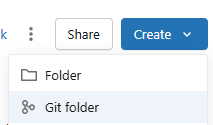

   Já fizemos no LAB 2, mas se ainda não fez, adicione o endereço https://github.com/Escola-de-Matematica-Aplicada/EDIA-Labs-DataBricks.git

3. Na pasta `EDIA-Labs-DataBricks`, abra `Labs` e execute apenas `lodlog_lab3_seed_v3` (o script `lodlog_modelo_dados_v3.sql` já foi rodado no LAB 2).
4. Com o notebook aberto, clique em **Run all** no canto superior direito. Certifique-se de que a opção **Serverless** está selecionada.

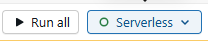

   O script leva cerca de 2 minutos. Ele carrega dados aleatórios no banco operacional `lodlog_op` e no analítico `lodlog_dw` (Star Schema), populando a tabela fato com 50.000 entregas fictícias.

5. Após a execução do seed terminar com sucesso, volte a **este notebook** para desenvolver as atividades do LAB.
6. Execute a célula abaixo para selecionar o banco:

In [ ]:
%sql
USE lodlog_dw;
SHOW TABLES;

> **Sobre as janelas de tempo:** os dados sintéticos vão até 30/09/2026. Para que filtros como "últimos 90 dias" sempre retornem dados, usamos a **data mais recente da base** como referência — `(SELECT MAX(data_entrega) FROM fato_entregas)` — no lugar de `CURRENT_DATE`. Em produção, com dados atualizados diariamente, você usaria `CURRENT_DATE`.

## Parte 1 — Análise Exploratória com SQL (25 min)

### Atividade 1.1: Conhecendo os Dados do DW (10 min, individual)

As tabelas do modelo dimensional analítico estão no schema `lodlog_dw`. Execute e interprete as três queries analíticas abaixo. Escreva uma frase curta de interpretação sobre o que o resultado revela para a gestão da LODLog.

In [ ]:
%sql
-- Query 1: Volume de entregas e atrasos por mês
SELECT DATE_TRUNC('month', data_entrega) AS mes,
       COUNT(*) AS total_entregas,
       SUM(CASE WHEN minutos_atraso > 0 THEN 1 ELSE 0 END) AS entregas_atrasadas
FROM fato_entregas
GROUP BY 1
ORDER BY 1;

**Sua interpretação:**

In [ ]:
%sql
-- Query 2: Ranking de Centros de Distribuição (CD) por eficiência operacional
SELECT cd.codigo AS cd_origem,
       ROUND(AVG(fe.minutos_atraso), 2) AS atraso_medio_min,
       ROUND(SUM(fe.custo_combustivel + fe.custo_pedagio), 2) AS custo_total_operacional,
       COUNT(DISTINCT fe.sk_veiculo) AS frota_alocada
FROM fato_entregas fe
INNER JOIN dim_centro_distribuicao cd ON fe.sk_cd_origem = cd.sk_cd
WHERE fe.data_entrega >= (SELECT MAX(data_entrega) FROM fato_entregas) - INTERVAL '90 days'
GROUP BY cd.codigo
ORDER BY atraso_medio_min ASC;

**Sua interpretação:**

In [ ]:
%sql
-- Query 3: Correlação estatística simples entre a distância percorrida e o custo de combustível
SELECT corr(distancia_km, custo_combustivel) AS correlacao_distancia_custo
FROM fato_entregas
WHERE data_entrega >= (SELECT MAX(data_entrega) FROM fato_entregas) - INTERVAL '30 days';

**Sua interpretação:**

### Atividade 1.2: Sua Primeira Query Analítica (15 min, individual)

Escreva uma consulta SQL para responder à seguinte pergunta da diretoria comercial:

**"Qual o percentual de entregas no prazo por cliente nos últimos 90 dias, considerando apenas clientes com mais de 10 entregas realizadas no período?"**

**Dicas de implementação:**

* Faça um `INNER JOIN` entre a fato `fato_entregas` e a dimensão `dim_cliente` (utilizando as surrogate keys).
* Filtre a data de entrega com `WHERE fe.data_entrega >= (SELECT MAX(data_entrega) FROM fato_entregas) - INTERVAL '90 days'`.
* Use `GROUP BY` na coluna `razao_social` do cliente.
* Filtre o total de grupos utilizando `HAVING COUNT(*) > 10`.
* Calcule o percentual de pontualidade: considere uma entrega "no prazo" se `indicador_atraso = 0` (equivale a `minutos_atraso <= 0`). Divida o volume pontual pelo total de entregas e multiplique por 100 (arredonde com `ROUND(..., 2)`).
* Ordene do menor percentual de pontualidade (piores clientes) para o maior.

In [ ]:
%sql
-- Escreva sua query de pontualidade aqui

## Parte 2 — Window Functions e Séries Temporais (25 min)

### Atividade 2.1: Média Móvel de Atrasos por CD (10 min, individual)

Métricas de tempo de atraso diário são ruidosas. Para suavizar as tendências em relatórios de BI, a gerência pediu para calcular a **média móvel das últimas 7 entregas** de cada centro de distribuição.

Escreva a query que retorne o CD (código), a data da entrega, o atraso individual da linha e a média móvel das últimas 7 linhas daquele mesmo CD (ordenadas por data).

**Dica Spark SQL:** use `AVG(minutos_atraso) OVER (PARTITION BY sk_cd_origem ORDER BY data_entrega ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)`. Para exibir o código amigável do CD, faça o JOIN com `dim_centro_distribuicao`.

In [ ]:
%sql
-- Escreva sua query de média móvel aqui

### Atividade 2.2: Ranking de Eficiência da Frota (10 min, individual)

Escreva uma consulta que analise o custo de combustível por quilômetro rodado de cada motorista (tabela `dim_motorista`) nos últimos 30 dias da base. A query deve classificar os motoristas em **quartis (1 a 4)** utilizando a window function `NTILE` e calcular o **percentil** de eficiência utilizando `PERCENT_RANK()`.

**Dica de estrutura:** crie uma CTE agrupando as entregas por `sk_motorista` para obter o custo de combustível por km (`SUM(custo_combustivel) / NULLIF(SUM(distancia_km), 0)`). Em seguida, na consulta principal, faça um JOIN com `dim_motorista` e aplique `NTILE(4) OVER (ORDER BY custo_por_km ASC)` e `PERCENT_RANK() OVER (ORDER BY custo_por_km ASC)`.

In [ ]:
%sql
-- Escreva sua query de ranking de motoristas aqui

### Atividade 2.3: Discussão Analítica (5 min, em grupo)

Debata com seu grupo: do ponto de vista de arquitetura de banco de dados e plano de execução (`EXPLAIN`), por que as **Window Functions** são computacionalmente mais eficientes no Spark SQL do que implementar a mesma lógica utilizando subqueries correlacionadas clássicas?

## Parte 3 — Feature Engineering em SQL (30 min)

### Atividade 3.1: Crie a View de Feature Store `vw_features_ml` (20 min, em grupo)

Os cientistas de dados precisam treinar um modelo preditivo de probabilidade de atraso. O modelo exige que cada linha represente **uma entrega**, com um identificador, **8 variáveis explicativas (features)** e a variável resposta (target).

Crie a view analítica `vw_features_ml` no banco `lodlog_dw` com as seguintes colunas:

| Nome da Feature | Tipo/Origem | Fórmula / Lógica de Extração em SQL |
| --- | --- | --- |
| sk_entrega | Identificador | Chave surrogate da entrega (já existe em `fato_entregas`) |
| distancia_km | Numérica (Fato) | `distancia_km` (da fato) |
| peso_total_kg | Numérica (Fato) | `peso_total_kg` (da fato) |
| hora_saida | Numérica (Derivada) | `hour(hora_saida)` ou `EXTRACT(HOUR FROM hora_saida)` |
| dia_semana | Numérica (Derivada) | `dayofweek(data_entrega)` (1 = Domingo, 7 = Sábado) |
| eh_feriado | Booleana (Dimensão) | Coluna `flag_feriado` da `dim_tempo` (requer JOIN) |
| temperatura_media_motor | Numérica (IoT) | Coluna `temperatura_media_motor` (já presente na fato) |
| historico_atrasos_7d | Janela (Móvel) | Média de atraso (minutos) das **7 entregas anteriores** do mesmo cliente, via Window Function |
| dias_ultima_manutencao | Diferença (Histórica) | Dias entre `data_entrega` e a conclusão da última manutenção do veículo **até aquela data** (requer JOIN com `lodlog_op.manutencao` filtrando `status = 'Concluída'`) |
| target_atraso | Variável Resposta | `indicador_atraso` da fato (0 = no prazo, 1 = atrasado) |

Três cuidados, todos vistos em aula, estão comentados no código:

* **Grain:** a view deve ter exatamente uma linha por entrega. Por isso as CTEs devolvem uma linha por `sk_entrega` e os JOINs são feitos por ela.
* **Surrogate × natural key:** a fato guarda `sk_veiculo` (chave do DW); a `manutencao` guarda `veiculo_id` (chave do sistema operacional). A ponte entre as duas é a `dim_veiculo`.
* **Vazamento do target:** o histórico do cliente usa só entregas **anteriores** (`1 PRECEDING`); se incluísse a linha atual, a feature conteria o próprio atraso que o modelo quer prever.

In [ ]:
%sql
CREATE OR REPLACE VIEW lodlog_dw.vw_features_ml AS
WITH hist_cliente AS (
  -- Média de atraso das 7 entregas ANTERIORES do mesmo cliente (sem a entrega atual)
  SELECT sk_entrega,
         AVG(minutos_atraso) OVER (
           PARTITION BY sk_cliente
           ORDER BY data_entrega, hora_saida
           ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
         ) AS hist_7d
  FROM fato_entregas
),
ultima_manutencao AS (
  -- Última manutenção concluída de cada veículo até a data da entrega
  SELECT fe.sk_entrega,
         MAX(m.data_conclusao) AS data_conclusao
  FROM fato_entregas fe
  INNER JOIN dim_veiculo dv          ON fe.sk_veiculo = dv.sk_veiculo   -- surrogate key (DW)
  INNER JOIN lodlog_op.manutencao m  ON m.veiculo_id  = dv.veiculo_id   -- natural key (OLTP)
  WHERE m.status = 'Concluída'
    AND CAST(m.data_conclusao AS DATE) <= fe.data_entrega
  GROUP BY fe.sk_entrega
)
SELECT
  fe.sk_entrega,
  fe.distancia_km,
  fe.peso_total_kg,
  hour(fe.hora_saida)                           AS hora_saida,
  dayofweek(fe.data_entrega)                    AS dia_semana,
  dt.flag_feriado                               AS eh_feriado,
  fe.temperatura_media_motor,
  ROUND(h.hist_7d, 2)                           AS historico_atrasos_7d,
  DATEDIFF(fe.data_entrega, um.data_conclusao)  AS dias_ultima_manutencao,
  fe.indicador_atraso                           AS target_atraso
FROM fato_entregas fe
INNER JOIN dim_tempo dt           ON fe.sk_data = dt.sk_tempo
LEFT JOIN hist_cliente h          ON fe.sk_entrega = h.sk_entrega
LEFT JOIN ultima_manutencao um    ON fe.sk_entrega = um.sk_entrega;

In [ ]:
%sql
-- Conferência do grain: a view deve ter o mesmo número de linhas da fato
SELECT (SELECT COUNT(*) FROM vw_features_ml) AS linhas_view,
       (SELECT COUNT(*) FROM fato_entregas)  AS linhas_fato;

---

**— linha de base —** A partir daqui é opcional.

### Atividade 3.2: Valide a Feature Store (10 min, individual)

Execute as queries de validação na view recém-criada e documente os resultados:

1. **Completude:** há registros com dados de manutenção nulos? O que isso indica?

In [ ]:
%sql
SELECT COUNT(*) FROM vw_features_ml WHERE dias_ultima_manutencao IS NULL;

2. **Distribuição do Target:** o dataset está balanceado em termos de atrasos?

In [ ]:
%sql
SELECT target_atraso,
       COUNT(*) AS volume,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM vw_features_ml
GROUP BY 1;

3. **Dashboard:** monte um dashboard para acompanhar o **percentual de atrasos por dia da semana**.

   **Dashboards** → **Create dashboard** → aba **Data** → **Add data** → escolha a view recém-criada (`vw_features_ml`).

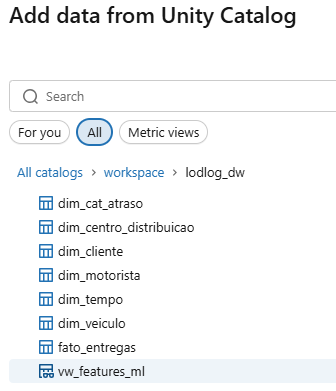

   Com isso a view passa a ser uma fonte de dados do dashboard. Na aba do dashboard, adicione uma visualização com essa fonte:

   * **Visualization:** Bar (dia da semana é uma categoria; prefira barras a linhas)
   * **X axis:** `dia_semana`
   * **Y axis:** `AVG(target_atraso)` — a média do target é o percentual de atrasos

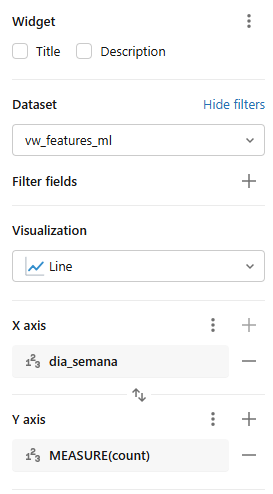

   *(a figura mostra onde ficam os campos; ajuste Visualization e Y axis conforme acima)*

4. **Correlação com a Variável Alvo:** a quilometragem rodada está correlacionada com o atraso?

In [ ]:
%sql
SELECT corr(distancia_km, target_atraso) AS correlacao_dist_target FROM vw_features_ml;

## Parte 4 — Qualidade de Dados via SQL (15 min)

### Atividade 4.1: Auditoria Automática de Dados (10 min, individual)

O notebook de seed introduziu anomalias operacionais na tabela fato para simular problemas de pipelines em produção. Escreva consultas SQL que detectem as seguintes inconsistências em `lodlog_dw.fato_entregas`:

1. **Registros Duplicados:** encontre registros que tenham o mesmo `entrega_id` (deveria ser único pelo grain).

In [ ]:
%sql
-- Escreva sua query para encontrar entrega_id duplicados

2. **Valores Inválidos / Negativos:** detecte registros com campos físicos negativos que violam a lógica de negócio (distância, peso ou custos).

In [ ]:
%sql
-- Escreva sua query para valores negativos

3. **Outliers de Tempo:** identifique registros com tempos de atraso absurdamente altos (ex: atrasos maiores que 24 horas / 1440 min) ou adiantamentos fisicamente impossíveis (adiantados mais de 8 horas / -480 min).

In [ ]:
%sql
-- Escreva sua query para outliers de atraso/adiantamento

4. **Inconsistência de Integridade (Órfãos):** utilize uma query do tipo **Anti-Join** (`LEFT JOIN ... IS NULL`) para identificar entregas na fato que apontam para clientes (`sk_cliente`) inexistentes em `dim_cliente`.

In [ ]:
%sql
-- Escreva sua query de auditoria referencial (Anti-Join)

### Atividade 4.2: Conexão com o Trabalho em Grupo (5 min, em grupo)

Para cada tipo de anomalia identificado no banco multidimensional:

* Qual a causa provável desse erro na ingestão ou nos sistemas de origem?
* Como você implementaria a limpeza e a conformidade dessa variável nas camadas **Bronze e Silver** do seu pipeline (arquitetura Medallion, aprofundada na Aula 4)?